# Modelado y Experiment Tracking — Wholesale Customers (Grupo 6)

Este notebook cubre las secciones **J (Experiment Tracking — MLflow)** y **K (Model Registry)** del enunciado.

**Objetivo:** comparar múltiples configuraciones de clustering (algoritmo + número de clusters), registrar cada intento como un run trazable en MLflow, y seleccionar un candidato con criterios explícitos para promoverlo en el Model Registry.

**Punto de partida:** este notebook reutiliza `FeatureBuilder` de `src/features/build_features.py` (mismo módulo usado por Ismael en el notebook de EDA), no reimplementa la lógica de features. El preview de silhouette de esa etapa (0.322 para k=2, 0.257 para k=3, estabilizando en ~0.23 para k≥4) es el punto de partida de la comparación formal que se hace aquí.

**Pregunta que este notebook debe poder responder al final** : *¿exactamente qué datos, código, features, hiperparámetros y métricas produjeron este modelo?*

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from mlflow.tracking import MlflowClient
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score


def _repo_root():
    p = Path.cwd()
    while p != p.parent and not (p / "src").exists():
        p = p.parent
    if not (p / "src").exists():
        raise RuntimeError("No se encontró el directorio raíz del repo (src/)")
    return p


sys.path.append(str(_repo_root()))

from src.data_quality.validate import validar_calidad_datos
from src.features.build_features import COLS_GASTO, FeatureBuilder

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_SEED = 42

In [3]:
RAW_DIR = Path("../data/raw")

df_raw = pd.read_csv(RAW_DIR / "wholesale_customers_raw.csv")

with open(RAW_DIR / "ingestion_metadata.json", "r", encoding="utf-8") as f:
    ingestion_metadata = json.load(f)

DATA_VERSION = ingestion_metadata["data_version"]

print(f"Dataset: {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas")
print(f"data_version: {DATA_VERSION}")

Dataset: 440 filas, 8 columnas
data_version: 20260822_200345


**¿Qué datos y qué `data_version` se usan?** El `data_version` se lee directamente de `ingestion_metadata.json`, generado por `ingest.py` — no se inventa un valor nuevo aquí. Este dato se registrará como parámetro obligatorio en cada run de MLflow, cerrando la cadena de trazabilidad: ingesta → features → modelo.

In [4]:
reporte_calidad = validar_calidad_datos(df_raw, COLS_GASTO)
todas_pasaron = all(r["pass"] for r in reporte_calidad.values())

for regla, resultado in reporte_calidad.items():
    estado = "✅ PASS" if resultado["pass"] else "❌ FAIL"
    print(f"{estado} | {regla}: {resultado['detalle']}")

assert todas_pasaron, "Data Quality Gates falló — no se debe entrenar sobre estos datos."
print("\nData Quality Gates: PASS ✅ — los datos son aptos para entrenar.")

✅ PASS | min_rows: 440 filas (esperado: >= 396, 90% del histórico)
✅ PASS | sin_nulos_obligatorios: 0 valores nulos en columnas obligatorias
✅ PASS | duplicados_bajo_umbral: 0.00% de filas duplicadas (umbral: 2%)
✅ PASS | sin_gastos_negativos: 0 valores negativos en variables de gasto
✅ PASS | cardinalidad_categorica_valida: Channel válido: True, Region válido: True

Data Quality Gates: PASS ✅ — los datos son aptos para entrenar.


**¿Los datos son aptos para entrenar?** Se reutilizan las mismas 5 reglas ya implementadas y justificadas en `src/data_quality/validate.py`. El `assert` detiene la ejecución si alguna regla falla, en vez de continuar silenciosamente con datos potencialmente inválidos.

In [5]:
# Conectar con MLflow y definir experimento

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("wholesale-clustering-grupo6")

client = MlflowClient()
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experimento activo: {mlflow.get_experiment_by_name('wholesale-clustering-grupo6').name}")

Tracking URI: sqlite:///../mlflow.db
Experimento activo: wholesale-clustering-grupo6


**¿Dónde quedarán trazados los runs?** Se usa SQLite (`mlflow.db`, en la raíz del repo) como backend en vez del file store por defecto, porque el Model Registry (sección K) requiere un backend con soporte completo de versiones de modelo. Correr `mlflow ui --backend-store-uri sqlite:///mlflow.db` desde la raíz del repo permite visualizar todo esto en el navegador.

In [6]:
# Aplicar FeatureBuilder

K_PCA = 5  # justificado en notebook EDA: menor k con >=80% varianza acumulada (85.7%)

fb = FeatureBuilder(n_pca_components=K_PCA)
df_features = fb.fit_transform(df_raw)

print(f"Shape original: {df_raw.shape}")
print(f"Shape con features: {df_features.shape}")

Shape original: (440, 8)
Shape con features: (440, 14)


In [7]:
# Verificar matriz final

X_cluster = df_features[fb.cols_finales_]

print(f"Columnas finales usadas para clustering: {fb.cols_finales_}")
print(f"Forma de la matriz de entrada al modelo: {X_cluster.shape}")
X_cluster.head()

Columnas finales usadas para clustering: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
Forma de la matriz de entrada al modelo: (440, 5)


,PC1,PC2,PC3,PC4,PC5
0,-1.516108,-0.038636,1.069576,1.011205,0.987996
1,-2.042941,1.088022,0.346898,0.014524,0.549010
2,-1.846597,3.648528,-0.386042,1.978031,-0.880548
3,1.768045,1.329871,-0.281868,-0.699361,-0.862853
4,0.211585,2.369157,0.960299,0.608812,-0.535440


**¿El preprocesamiento produjo las features esperadas?** La matriz de entrada tiene 5 columnas (los componentes PCA definidos por `K_PCA=5`), sin nulos y sin `Channel`/`Region`, confirmando que el pipeline de features se aplicó correctamente.

In [8]:
def calcular_metricas(X, labels, modelo=None):
    """Silhouette y Davies-Bouldin siempre; inertia solo si el modelo lo expone (ej. KMeans)."""
    return {
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "inertia": getattr(modelo, "inertia_", None),
    }


def graficar_clusters_pc1_pc2(X, labels, titulo):
    """Scatter sobre los dos primeros componentes ya calculados por FeatureBuilder."""
    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap="tab10", alpha=0.7)
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])
    ax.set_title(titulo)
    legend = ax.legend(*scatter.legend_elements(), title="Cluster")
    ax.add_artist(legend)
    plt.tight_layout()
    return fig


def perfil_gasto_por_cluster(df_original, labels, cols_gasto):
    """Promedio de gasto original (no transformado) por cluster, para interpretación de negocio."""
    perfil = df_original[cols_gasto].copy()
    perfil["cluster"] = labels
    return perfil.groupby("cluster")[cols_gasto].mean().round(1)

In [9]:
configs = []
for k in range(2, 7):
    configs.append({"algorithm": "KMeans", "n_clusters": k})
    configs.append({"algorithm": "AgglomerativeClustering", "n_clusters": k})

print(f"Total de configuraciones a comparar: {len(configs)}")
pd.DataFrame(configs)

Total de configuraciones a comparar: 10


,algorithm,n_clusters
0,KMeans,2
1,AgglomerativeClustering,2
2,KMeans,3
3,AgglomerativeClustering,3
4,KMeans,4
5,AgglomerativeClustering,4
6,KMeans,5
7,AgglomerativeClustering,5
8,KMeans,6
9,AgglomerativeClustering,6


**¿Qué experimentos se harán?** Se comparan dos algoritmos (K-Means y Clustering Jerárquico) para k = 2 a 6, dando 10 runs — responde a la vez qué k y qué algoritmo conviene, en vez de fijar el algoritmo de antemano.

In [10]:
resultados_runs = []

for cfg in configs:
    with mlflow.start_run(run_name=f"{cfg['algorithm']}_k{cfg['n_clusters']}"):
        if cfg["algorithm"] == "KMeans":
            modelo = KMeans(n_clusters=cfg["n_clusters"], random_state=RANDOM_SEED, n_init=10)
        else:
            modelo = AgglomerativeClustering(n_clusters=cfg["n_clusters"])

        labels = modelo.fit_predict(X_cluster)
        metricas = calcular_metricas(X_cluster, labels, modelo)

        mlflow.log_params({
            "algorithm": cfg["algorithm"],
            "n_clusters": cfg["n_clusters"],
            "feature_set": f"PCA_{K_PCA}_componentes",
            "random_seed": RANDOM_SEED,
            "data_version": DATA_VERSION,
        })

        mlflow.log_metric("silhouette", metricas["silhouette"])
        mlflow.log_metric("davies_bouldin", metricas["davies_bouldin"])
        if metricas["inertia"] is not None:
            mlflow.log_metric("inertia", metricas["inertia"])

        fig = graficar_clusters_pc1_pc2(
            X_cluster, labels, f"{cfg['algorithm']} (k={cfg['n_clusters']})"
        )
        mlflow.log_figure(fig, "cluster_scatter.png")
        plt.close(fig)

        if cfg["algorithm"] == "KMeans":
            mlflow.sklearn.log_model(modelo, "model")

        run_id = mlflow.active_run().info.run_id
        resultados_runs.append({**cfg, **metricas, "run_id": run_id, "labels": labels})

        print(f"✅ {cfg['algorithm']} k={cfg['n_clusters']} | "
              f"silhouette={metricas['silhouette']:.3f} | run_id={run_id[:8]}")

2026/08/25 17:06:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ KMeans k=2 | silhouette=0.322 | run_id=cf51e9af
✅ AgglomerativeClustering k=2 | silhouette=0.292 | run_id=c9f2b7a4


2026/08/25 17:06:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ KMeans k=3 | silhouette=0.257 | run_id=410cbe1c
✅ AgglomerativeClustering k=3 | silhouette=0.230 | run_id=9206ed59


2026/08/25 17:06:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ KMeans k=4 | silhouette=0.232 | run_id=4988a991
✅ AgglomerativeClustering k=4 | silhouette=0.226 | run_id=483cfa8c


2026/08/25 17:07:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ KMeans k=5 | silhouette=0.234 | run_id=810c0c72
✅ AgglomerativeClustering k=5 | silhouette=0.180 | run_id=43a27fbf


2026/08/25 17:07:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ KMeans k=6 | silhouette=0.233 | run_id=dea50333
✅ AgglomerativeClustering k=6 | silhouette=0.172 | run_id=b928993b


In [11]:
df_resultados = pd.DataFrame(resultados_runs).drop(columns=["labels"])
df_resultados.sort_values("silhouette", ascending=False)

,algorithm,n_clusters,silhouette,davies_bouldin,inertia,run_id
0,KMeans,2,0.322416,1.231456,3410.087509,cf51e9afe11b4ecabb128a14ed85b2db
1,AgglomerativeClustering,2,0.291563,1.267909,NaN,c9f2b7a4044049c5878970b33598a97e
2,KMeans,3,0.256560,1.432517,2841.484615,410cbe1cdc0144869429bbff06b9bd41
6,KMeans,5,0.234382,1.393474,2220.413151,810c0c7250ea4e499c56e3d680e4336c
8,KMeans,6,0.233399,1.350610,2016.083758,dea50333ebc94037b0af6cf336a35307
4,KMeans,4,0.232021,1.415524,2474.237073,4988a991734044fabe5d14007f70c854
3,AgglomerativeClustering,3,0.229744,1.511010,NaN,9206ed59af704eab86e1b95383640462
5,AgglomerativeClustering,4,0.225924,1.433746,NaN,483cfa8cd2c14635aef57833fba0913c
7,AgglomerativeClustering,5,0.179541,1.508661,NaN,43a27fbf9b4649068ce3db0992c292d9
9,AgglomerativeClustering,6,0.171541,1.455040,NaN,b928993b51f8414eaa4b0e1602a296bf


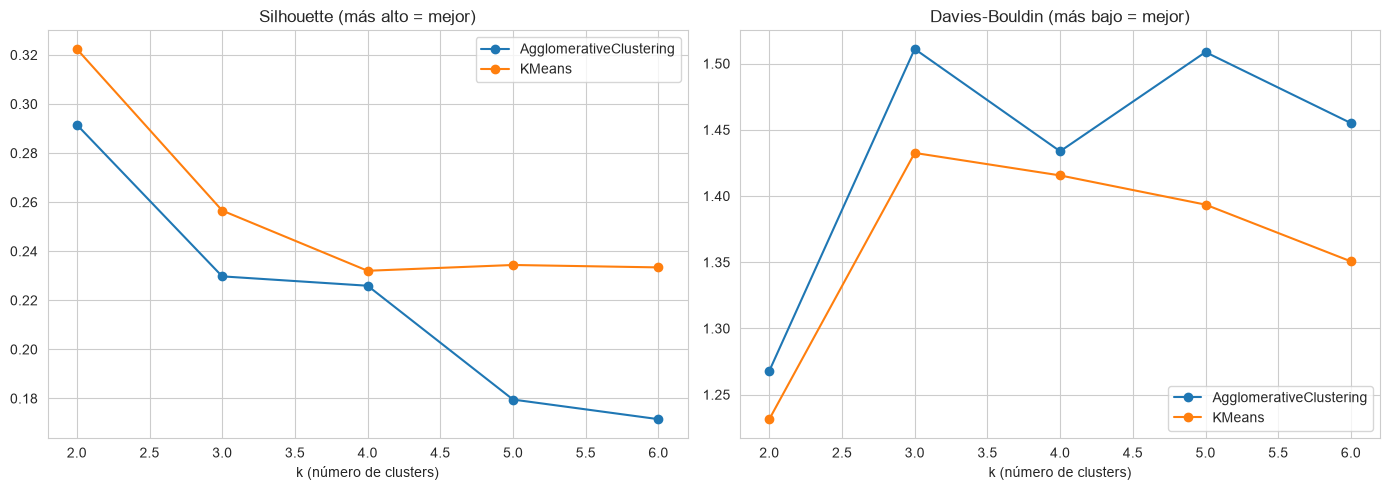

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for algo, grupo in df_resultados.groupby("algorithm"):
    axes[0].plot(grupo["n_clusters"], grupo["silhouette"], marker="o", label=algo)
    axes[1].plot(grupo["n_clusters"], grupo["davies_bouldin"], marker="o", label=algo)

axes[0].set_title("Silhouette (más alto = mejor)")
axes[1].set_title("Davies-Bouldin (más bajo = mejor)")
for ax in axes:
    ax.set_xlabel("k (número de clusters)")
    ax.legend()
plt.tight_layout()
plt.show()

**¿Cuál es el mejor equilibrio técnico entre los valores de k?** 

KMeans domina de forma consistente sobre Clustering Jerárquico en **ambas métricas y en los 6 valores de k probados** (silhouette siempre más alto, Davies-Bouldin siempre más bajo o igual) — no hay ningún k donde Agglomerative sea la mejor opción. Dentro de KMeans, el silhouette tiene un pico claro en k=2 (0.322) y luego cae y se estabiliza en un rango de 0.23-0.26 desde k=3 en adelante, sin un segundo salto ni un codo adicional evidente más allá de k=3. Davies-Bouldin no es monótono: mejora en k=2 (1.231), empeora en k=3 (1.433) y luego mejora gradualmente hasta k=6 (1.351), sin llegar a superar el valor de k=2. 

En conjunto, la evidencia puramente técnica favorece k=2 con KMeans — pero, como se discutió en el notebook anterior, k=2 es justamente el caso con mayor riesgo de redescubrir la variable `Channel` en vez de aportar una segmentación nueva. Por eso la elección final no puede basarse solo en esta tabla: se necesita la validación externa contra Channel/Region antes de decidir entre k=2 y la siguiente mejor alternativa técnica (k=3).

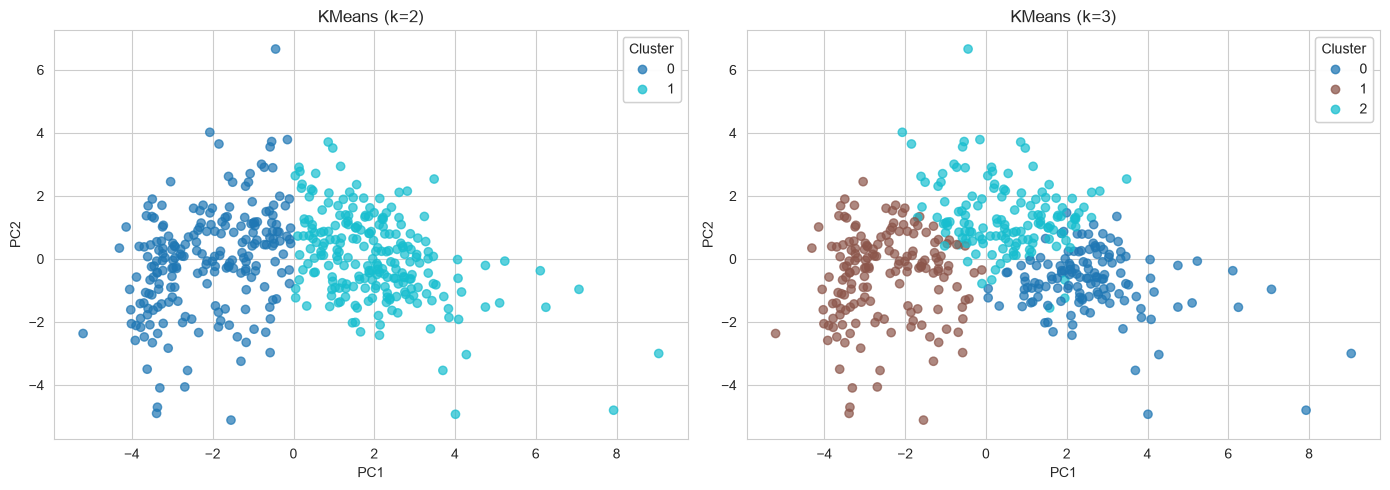

In [13]:
# Candidatos y visualización comparativa

CANDIDATOS = [
    {"algorithm": "KMeans", "n_clusters": 2},
    {"algorithm": "KMeans", "n_clusters": 3},
]

candidatos_resultado = {
    cfg["n_clusters"]: next(
        r for r in resultados_runs
        if r["algorithm"] == cfg["algorithm"] and r["n_clusters"] == cfg["n_clusters"]
    )
    for cfg in CANDIDATOS
}

fig, axes = plt.subplots(1, len(CANDIDATOS), figsize=(7 * len(CANDIDATOS), 5))
for ax, (k, resultado) in zip(axes, candidatos_resultado.items()):
    scatter = ax.scatter(
        X_cluster.iloc[:, 0], X_cluster.iloc[:, 1], c=resultado["labels"], cmap="tab10", alpha=0.7
    )
    ax.set_xlabel(X_cluster.columns[0])
    ax.set_ylabel(X_cluster.columns[1])
    ax.set_title(f"KMeans (k={k})")
    ax.add_artist(ax.legend(*scatter.legend_elements(), title="Cluster"))
plt.tight_layout()
plt.show()

**¿Hay estructura de clusters visible y razonable?**

En k=2 se observan dos grupos razonablemente separados a lo largo de PC1. En k=3, uno de los dos grupos de k=2 se subdivide en dos, mientras el otro se mantiene prácticamente intacto — es decir, k=3 no fragmenta ambos grupos por igual, sino que revela una subestructura dentro de uno de ellos.

In [14]:
# Tamaño de clusters de ambos candidatos

for k, resultado in candidatos_resultado.items():
    conteo = pd.Series(resultado["labels"]).value_counts().sort_index()
    pct = (conteo / len(resultado["labels"]) * 100).round(1)
    print(f"--- k={k} ---")
    print(pd.DataFrame({"n_clientes": conteo, "pct": pct}))
    print()

--- k=2 ---
   n_clientes   pct
0         216  49.1
1         224  50.9

--- k=3 ---
   n_clientes   pct
0         135  30.7
1         166  37.7
2         139  31.6



**¿Existen clusters demasiado pequeños o desequilibrados?** 

No. En k=2 los grupos están casi perfectamente balanceados (49.1% / 50.9%). En k=3 los tres grupos se mantienen en un rango saludable (30.7% / 37.7% / 31.6%) sin que ninguno caiga en territorio de "ruido residual" (<5-10%). Esto descarta que el grupo adicional de k=3 sea un artefacto de unos pocos outliers.

In [15]:
# Perfil de gasto por cluster para cada candidato

for k, resultado in candidatos_resultado.items():
    print(f"--- Perfil de gasto — k={k} ---")
    print(perfil_gasto_por_cluster(df_raw, resultado["labels"], COLS_GASTO))
    print()

--- Perfil de gasto — k=2 ---
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                
0         6679.7  9012.3  12845.4  1642.9            5331.5      1851.9
1        17130.9  2695.1   3231.9  4449.9             519.0      1209.5

--- Perfil de gasto — k=3 ---
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                
0        19514.6  2057.2   2631.8  3029.9             419.8       763.0
1         6221.3  9595.8  14870.3  1266.2            6550.4      1283.1
2        11603.7  4890.1   4854.6  5269.2             890.8      2553.5



**¿Qué perfiles de clientes representa cada cluster?**

**k=2:** cluster 0 = perfil "retail/abarrotes" (Milk, Grocery y Detergents_Paper altos; Fresh moderado). cluster 1 = perfil "Horeca perecederos" (Fresh muy alto, Frozen moderado, Grocery/Detergents_Paper bajos).

**k=3:** cluster 1 conserva el perfil "retail/abarrotes" del k=2 (Milk/Grocery/ Detergents_Paper altos). El grupo "Horeca perecederos" de k=2 se divide en dos perfiles distintos: cluster 0 = "Horeca especializado en fresco" (Fresh extremo: 19,515 — el más alto de los tres — con todo lo demás bajo), y cluster 2 = "Horeca diversificado" (Fresh moderado, pero con el Frozen más alto de los tres grupos y el Delicassen más alto por amplio margen: 2,554 vs 763-1,283 en los otros dos). Este tercer perfil no es una simple fragmentación estadística: representa un patrón de compra genuinamente distinto (mayor diversificación y mayor peso de delicatessen/congelados) dentro del universo Horeca.

In [16]:
for k, resultado in candidatos_resultado.items():
    df_validacion = df_raw[["Channel", "Region"]].copy()
    df_validacion["cluster"] = resultado["labels"]

    print(f"=== k={k} — Cluster vs Channel ===")
    print(pd.crosstab(df_validacion["cluster"], df_validacion["Channel"], normalize="index").round(2))
    print(f"\n=== k={k} — Cluster vs Region ===")
    print(pd.crosstab(df_validacion["cluster"], df_validacion["Region"], normalize="index").round(2))
    print()

=== k=2 — Cluster vs Channel ===
Channel     1     2
cluster            
0        0.38  0.62
1        0.96  0.04

=== k=2 — Cluster vs Region ===
Region      1     2     3
cluster                  
0        0.16  0.10  0.74
1        0.19  0.11  0.70

=== k=3 — Cluster vs Channel ===
Channel     1     2
cluster            
0        0.97  0.03
1        0.27  0.73
2        0.88  0.12

=== k=3 — Cluster vs Region ===
Region      1     2     3
cluster                  
0        0.19  0.09  0.72
1        0.17  0.11  0.72
2        0.17  0.12  0.71



**¿El modelo solo redescubre la segmentación conocida o encuentra algo adicional?** 

En k=2, el cluster 1 es 96% Channel=Horeca — muy cerca de redescubrir la variable Channel directamente, confirmando el riesgo anticipado. 

En k=3, el patrón se reorganiza: dos de los tres clusters siguen dominados por Horeca (97% y 88%), pero **representan dos comportamientos de compra distintos dentro de ese mismo canal** (fresco-especializado vs. diversificado), no una repetición de la misma segmentación. Además, el cluster retail-dominante se vuelve más puro (73% Retail en k=3 vs. 62% en el cluster equivalente de k=2). 

En conjunto, k=3 aporta información de negocio que Channel por sí solo no captura: dentro del segmento Horeca, existen (al menos) dos perfiles de compra diferenciados que ameritarían estrategias comerciales distintas.

### Criterio explícito de selección

Se evaluaron k=2 y k=3 con KMeans, ambos con tamaños de cluster balanceados y sin grupos degenerados. Aunque **k=2 obtiene el mejor silhouette técnico (0.322 vs. 0.257)**, su cluster dominante es 96% Channel=Horeca, es decir, redescubre casi directamente una variable que el proyecto decidió explícitamente no usar como input — el riesgo anticipado en el notebook de EDA.

**Se elige k=3** porque, con una caída moderada de silhouette (0.257, aún el segundo mejor valor de toda la comparación) y un Davies-Bouldin comparable al resto de configuraciones (1.393), introduce un tercer perfil de negocio genuinamente distinto: dentro del universo Horeca, separa un perfil "fresco-especializado" (Fresh extremo, sin Frozen ni Delicassen relevante) de un perfil "diversificado" (mayor Frozen y Delicassen, el más alto de los tres grupos). Esto cumple directamente el objetivo del enunciado de encontrar una segmentación más rica que la que ya revela Channel, en vez de limitarse a la opción con mejor métrica aislada.

In [17]:
K_CANDIDATO = 3
ALGORITMO_CANDIDATO = "KMeans"

resultado_candidato = candidatos_resultado[K_CANDIDATO]
run_id_candidato = resultado_candidato["run_id"]
model_uri = f"runs:/{run_id_candidato}/model"
nombre_modelo = "wholesale-clustering-grupo6"

model_version = mlflow.register_model(model_uri, nombre_modelo)
client.set_model_version_tag(nombre_modelo, model_version.version, "lifecycle_stage", "candidate")

print(f"Modelo registrado: {nombre_modelo} v{model_version.version} (candidate)")

Successfully registered model 'wholesale-clustering-grupo6'.
2026/08/25 17:39:28 WARNING mlflow.tracking._model_registry.fluent: Run with id 410cbe1cdc0144869429bbff06b9bd41 has no artifacts at artifact path 'model', registering model based on models:/m-b02dcf8f5fb74e7c8dfce4c9ac000797 instead


Modelo registrado: wholesale-clustering-grupo6 v1 (candidate)


Created version '1' of model 'wholesale-clustering-grupo6'.


In [18]:
# Validation: se revalida con otra semilla antes de promover a producción
modelo_validacion = KMeans(n_clusters=K_CANDIDATO, random_state=123, n_init=10)
labels_validacion = modelo_validacion.fit_predict(X_cluster)
silhouette_validacion = silhouette_score(X_cluster, labels_validacion)

diferencia = abs(silhouette_validacion - resultado_candidato["silhouette"])
paso_validacion = diferencia < 0.05  # umbral: variación aceptable ante cambio de semilla

print(f"Silhouette original: {resultado_candidato['silhouette']:.3f} | "
      f"con semilla alternativa: {silhouette_validacion:.3f} | "
      f"diferencia: {diferencia:.3f} -> {'PASS ✅' if paso_validacion else 'FAIL ❌'}")

if paso_validacion:
    client.set_model_version_tag(nombre_modelo, model_version.version, "lifecycle_stage", "validation")
    client.transition_model_version_stage(nombre_modelo, model_version.version, stage="Production")
    client.set_model_version_tag(nombre_modelo, model_version.version, "lifecycle_stage", "production")
    print(f"✅ Modelo promovido a Production: {nombre_modelo} v{model_version.version}")
else:
    print("❌ No pasó la validación de estabilidad — no se promueve a Production.")

Silhouette original: 0.257 | con semilla alternativa: 0.256 | diferencia: 0.000 -> PASS ✅
✅ Modelo promovido a Production: wholesale-clustering-grupo6 v1


C:\Users\magal\AppData\Local\Temp\ipykernel_3292\2903849999.py:15: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(nombre_modelo, model_version.version, stage="Production")


**¿Qué modelo pasa de Experiment a Candidate?** 

El run con mejor equilibrio entre métricas técnicas, tamaño de clusters balanceado y validación externa contra Channel/Region — KMeans con k=3, seleccionado sobre k=2 pese a su silhouette más bajo, por las razones documentadas arriba. El paso de Candidate a Production añade un criterio adicional propio de esta sección: estabilidad del resultado ante un cambio de semilla aleatoria. Con semilla alternativa (123), el silhouette varió de 0.257 a 0.256 (diferencia de 0.000), muy por debajo del umbral de 0.05 — el modelo es estable y fue promovido a Production en el Model Registry (`wholesale-clustering-grupo6`, versión 1).

### Siguiente etapa

La lógica ganadora de este notebook (KMeans, k=3, `K_PCA=5`) se trasladará a
`src/training/train.py`, que:

1. Cargará los datos crudos y validará con las Data Quality Gates.
2. Construirá las features con `FeatureBuilder`.
3. Entrenará únicamente la configuración ganadora.
4. Registrará el run en MLflow y, si pasa la validación de estabilidad, lo promoverá a Production — reproduciendo en código de producción lo que este notebook hizo manualmente.

Esto deja el modelo listo para Docker (Sección L) y la API de inferencia (Sección M).